In [83]:
#from analysis_tools_cython import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.backends.backend_pdf import PdfPages
import numpy as np
import lightkurve as lk

In [11]:
txt = pd.read_csv('../../k2/k2/candidates.txt',header=None)
columns = ['EPIC']
txt.columns = columns

In [69]:
campaign = [112,111,112,14,13,13,5,16,12,12,12,12,15,15,15,15,4,4,4,4,3,3,102,102,102,7,7,7,7,7,7,6,1,1,8,8,8,8,8,8,8]
#campaign = [11,11,11,14,13,13,5,16,12,12,12,12,15,15,15,15,4,4,4,4,3,3,102,102,102,7,7,7,7,7,7,6,1,1,8,8,8,8,8,8,8]

txt['campaign'] = campaign

In [70]:
full = pd.read_csv('../../k2/k2/k2-search-complete.csv')

In [71]:
data = pd.merge(txt,full,left_on='EPIC',right_on='ID')
data = data[data.transit_prob == 'maybeTransit']


In [72]:
# for i, row in txt.iterrows():
#     epic = row['EPIC']
#     campaign = row['campaign']
#     lc = lk.search_lightcurve(f'EPIC {epic}',author='EVEREST',mission='K2',campaign=campaign).download_all().stitch()
#     lc = lc[lc.quality == 0]
#     plt.figure(figsize=(10,2))
#     plt.title(f'EPIC {epic}, Campaign {campaign}')
#     plt.scatter(lc.time.value, lc.fcor.value/np.nanmedian(lc.fcor.value),s=3)
#     plt.show()

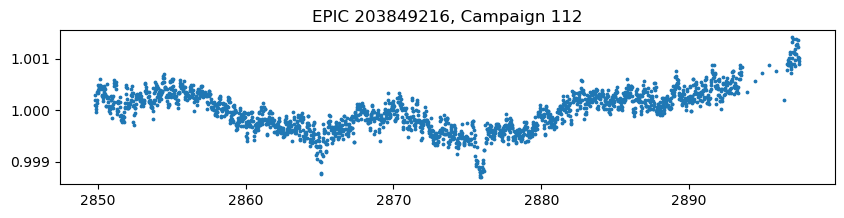

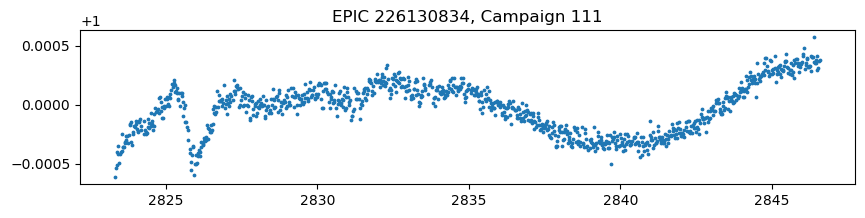

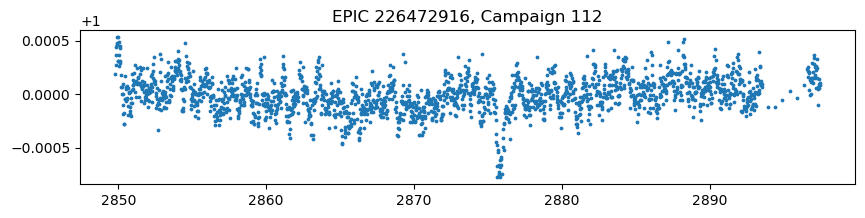

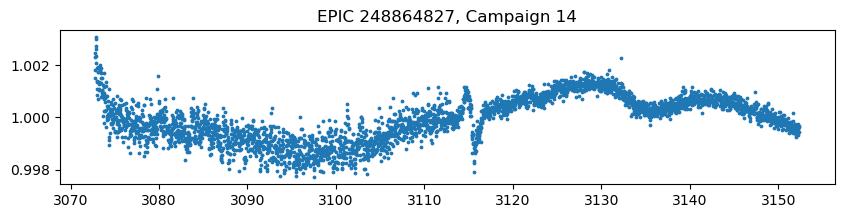

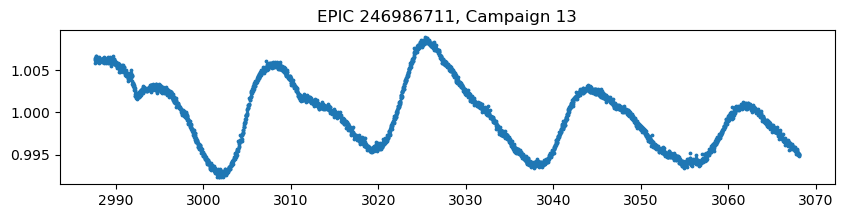

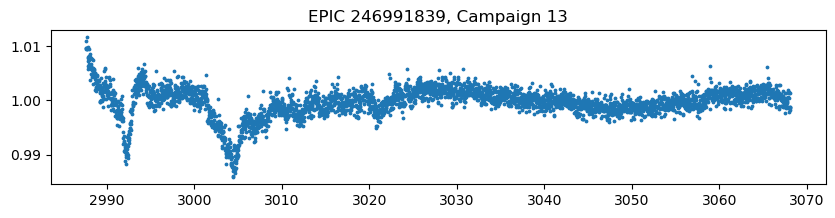

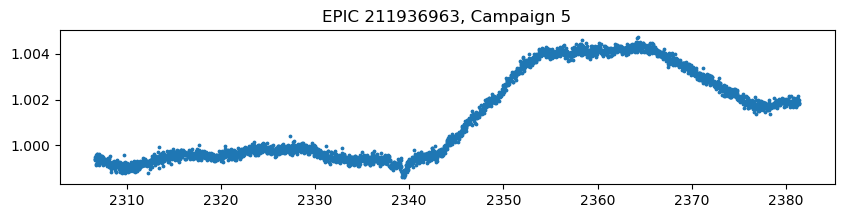

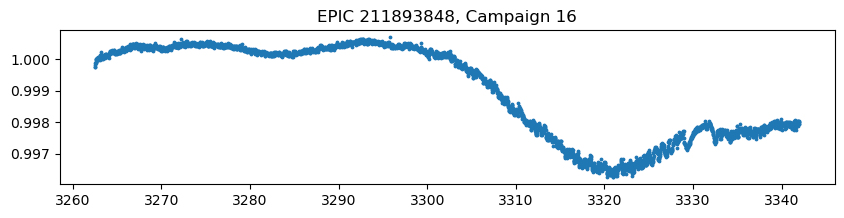

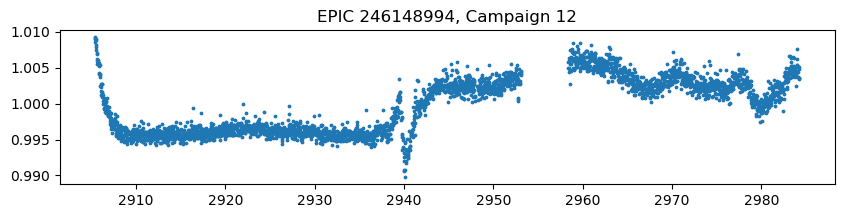

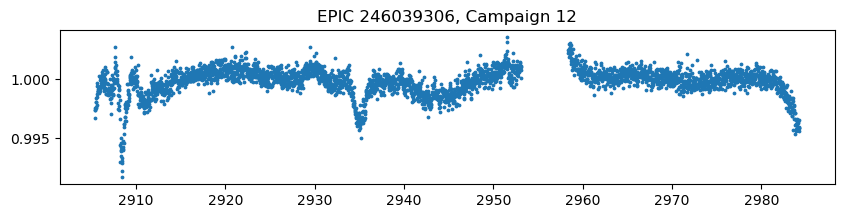

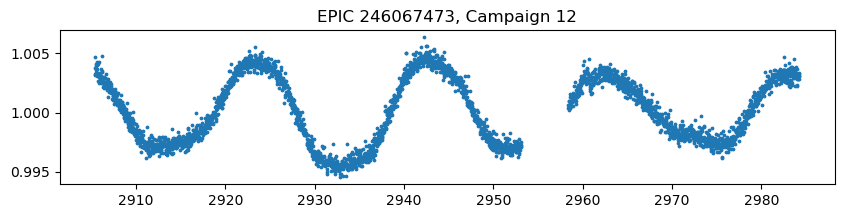

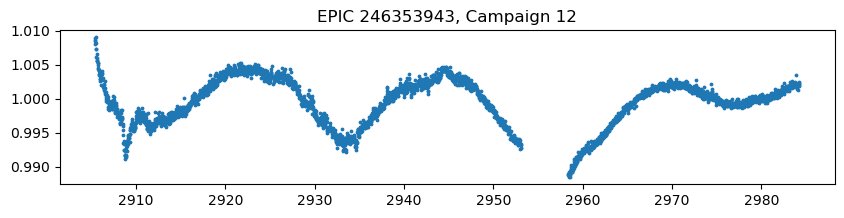

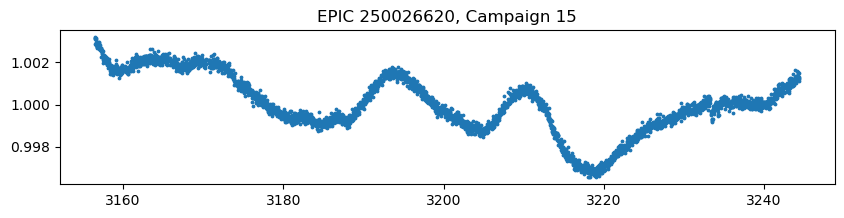

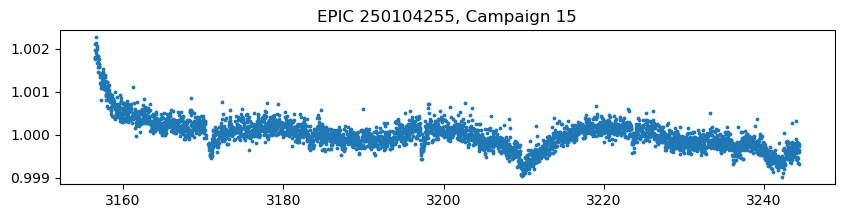

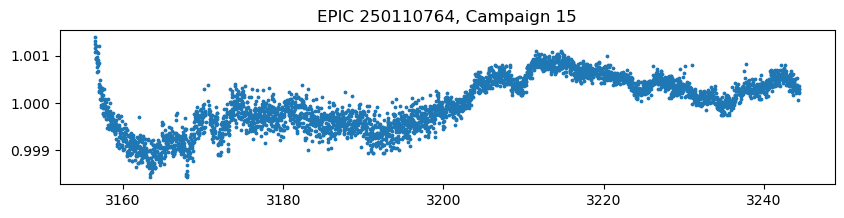

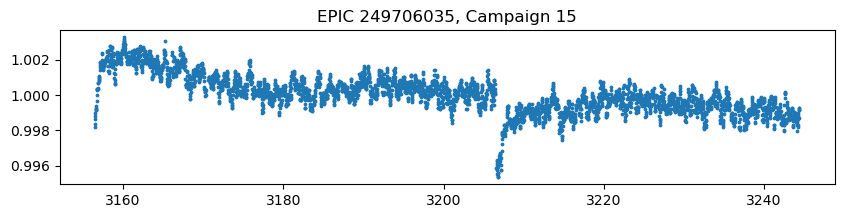

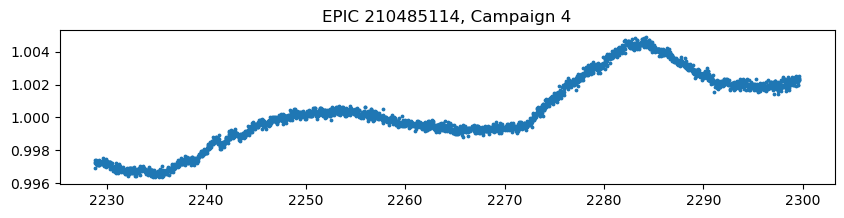

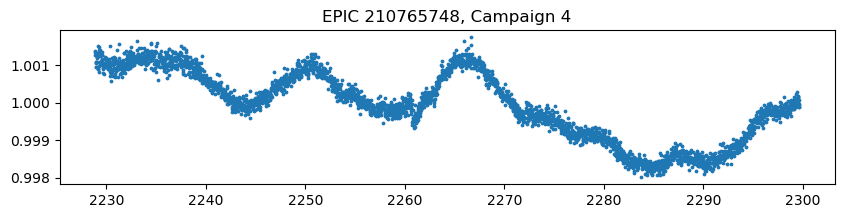

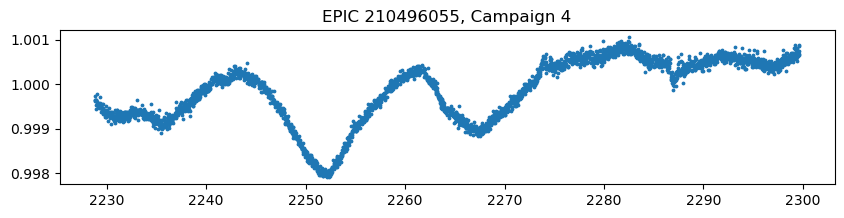

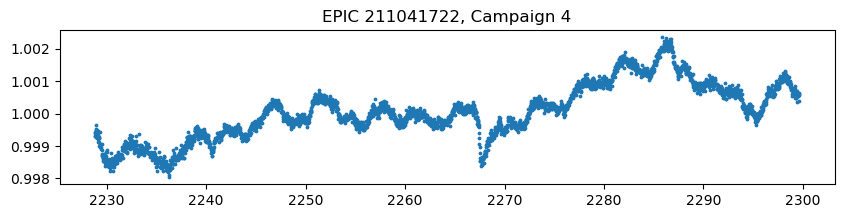

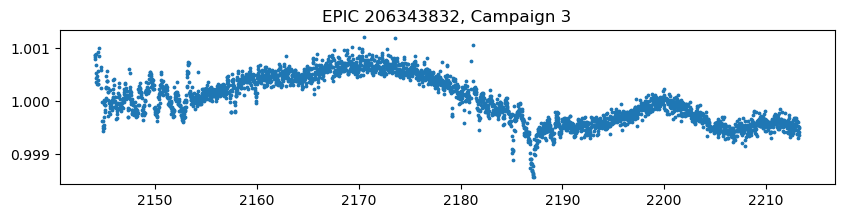

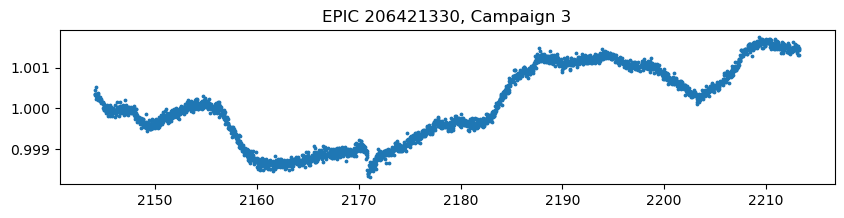

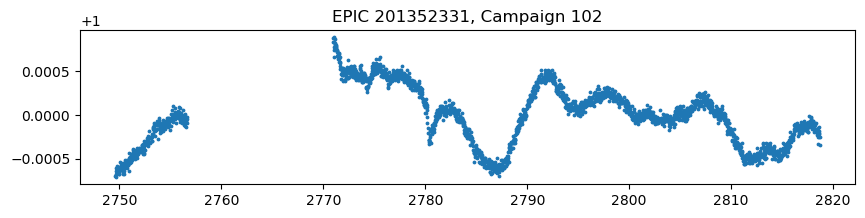

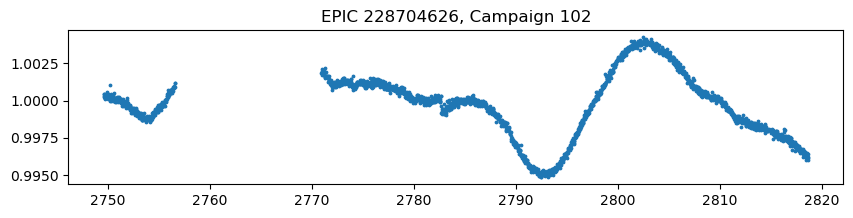

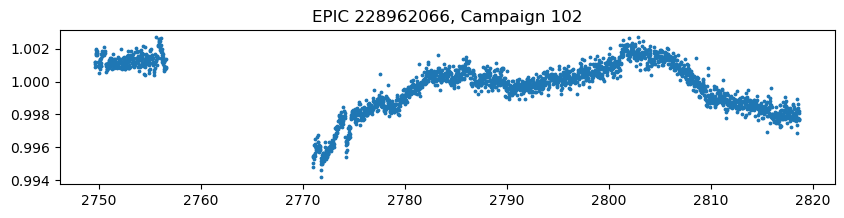

SSLError: HTTPSConnectionPool(host='mast.stsci.edu', port=443): Max retries exceeded with url: /api/v0.1/Download/file?uri=mast:HLSP/everest/v2/c07/219000000/01801/hlsp_everest_k2_llc_219001801-c07_kepler_v2.0_lc.fits (Caused by SSLError(SSLZeroReturnError(6, 'TLS/SSL connection has been closed (EOF) (_ssl.c:1149)')))

In [80]:
for i, row in txt.iterrows():
    epic = row['EPIC']
    campaign = row['campaign']

    # Map split campaigns back to real campaign numbers
    if campaign in [111, 112]:
        campaign_query = 11
    elif campaign in [101, 102]:
        campaign_query = 10
    else:
        campaign_query = campaign

    search = lk.search_lightcurve(f'EPIC {epic}', author='EVEREST',
                                  mission='K2', campaign=campaign_query)

    if campaign == 111:
        lc = search[0].download()
    elif campaign == 112:
        lc = search[1].download()
    elif campaign == 101:
        lc = search[0].download()
    elif campaign == 102:
        lc = search.download()
    else:
        lc = search.download()

    # Clean and plot
    lc = lc[lc.quality == 0]
    plt.figure(figsize=(10,2))
    plt.title(f'EPIC {epic}, Campaign {campaign}')
    plt.scatter(lc.time.value, lc.fcor.value / np.nanmedian(lc.fcor.value), s=3)
    plt.show()


In [124]:
data = data[(abs(data.snr) > 5) & (data.asym_score > 1.02) & (data.duration > 0.4)]

In [130]:
def find_correct_lightcurve(search_results, target_time):
   """
   Find the lightcurve that contains the target time.
   
   Parameters:
   search_results: lightkurve search results
   target_time: the transit time we're looking for
   
   Returns:
   lightcurve object or None if not found
   """
   for idx, lc_candidate in enumerate(search_results):
       try:
           test_lc = lc_candidate.download()
           test_lc = test_lc[test_lc.quality == 0]
           
           time_min = test_lc.time.value.min()
           time_max = test_lc.time.value.max()
           
           print(f"  Option {idx}: time range {time_min:.1f} to {time_max:.1f}")
           print(f"    Target time: {target_time:.1f}")
           
           if time_min <= target_time <= time_max:
               print(f"    ✓ Match found in option {idx}")
               return test_lc
               
       except Exception as e:
           print(f"  Option {idx}: Error downloading - {e}")
           continue
           
   print(f"  ✗ No lightcurve contains transit time {target_time:.1f}")
   return None

# Create a PDF file to save all figures
with PdfPages('candidate_lightcurves.pdf') as pdf:
   fig = None
   plot_count = 0
   
   for i, row in data.iterrows():
       epic = row['EPIC']
       campaign = row['campaign_x']
       transit_time = row['time']
       
       print(f"Processing EPIC {epic}, Campaign {campaign}, Transit time: {transit_time:.1f}")
       
       # Map split campaigns back to real campaign numbers
       if campaign in [111, 112]:
           campaign_query = 11
       elif campaign in [101, 102]:
           campaign_query = 10
       else:
           campaign_query = campaign
           
       search = lk.search_lightcurve(f'EPIC {epic}', author='EVEREST',
                                     mission='K2', campaign=campaign_query)
       
       print(f"Found {len(search)} lightcurve options")
       
       # Try to find the correct lightcurve first
       lc = find_correct_lightcurve(search, transit_time)
       
       # Fallback: if no match found, use the original logic
       if lc is None:
           print("  Using fallback logic...")
           if campaign == 111:
               lc = search[0].download()
           elif campaign == 112:
               lc = search[1].download()
           elif campaign == 101:
               lc = search[0].download()
           elif campaign == 102:
               lc = search.download()
           else:
               lc = search.download()
           
           # Clean the lightcurve
           lc = lc[lc.quality == 0]
       
       normalized_flux = lc.fcor.value / np.nanmedian(lc.fcor.value)
       
       # Verify the final lightcurve contains our transit time
       final_time_range = (lc.time.value.min(), lc.time.value.max())
       print(f"Final LC time range: {final_time_range[0]:.1f} to {final_time_range[1]:.1f}")
       transit_in_range = final_time_range[0] <= transit_time <= final_time_range[1]
       print(f"Transit time in range: {transit_in_range}")
       print("-" * 50)
       
       # Create new figure every 4 plots (4x1 vertical layout)
       if plot_count % 4 == 0:
           if fig is not None:
               plt.tight_layout()
               pdf.savefig(fig, bbox_inches='tight', dpi=150)
               plt.close(fig)
           
           fig = plt.figure(figsize=(8.27, 11.69))  # A4 portrait (210x297mm)
       
       # Calculate subplot position (4 rows, 1 column)
       subplot_idx = plot_count % 4
       
       # Create gridspec for this subplot (4 rows, 5 columns for the split layout)
       gs = gridspec.GridSpec(4, 5, figure=fig, 
                             left=0.08, right=0.95,
                             bottom=0.05, top=0.95,
                             hspace=0.5, wspace=0.2)
       
       # Large plot (left side) - takes columns 0-2
       ax1 = fig.add_subplot(gs[subplot_idx, :3])
       
       # Add shaded region in background (1.75 days either side of transit)
       shaded_width = 1.75
       ax1.axvspan(transit_time - shaded_width, transit_time + shaded_width, 
                  alpha=0.2, color='grey', zorder=0)
       
       ax1.scatter(lc.time.value, normalized_flux, s=1, alpha=0.7)
       ax1.set_title(f'EPIC {epic}, Campaign {campaign}', fontsize=13)
       ax1.set_xlabel('Time (BKJD)', fontsize=12)
       ax1.set_ylabel('Normalised Flux', fontsize=12)
       ax1.tick_params(labelsize=10)
       
       # Small zoomed plot (right side) - takes columns 3-4
       ax2 = fig.add_subplot(gs[subplot_idx, 3:], sharey=ax1)
       
       # Define zoom window around transit
       window_size = 3.5
       mask = (lc.time.value >= transit_time - window_size) & (lc.time.value <= transit_time + window_size)
       
       if np.any(mask) and transit_in_range:
           ax2.scatter(lc.time.value[mask], normalized_flux[mask], s=2, alpha=0.8, color='red')
           ax2.set_xlabel('Time (BKJD)', fontsize=12)
           ax2.set_title('Zoomed-in Transit',fontsize=13)
           ax2.tick_params(labelsize=10)
           ax2.tick_params(labelleft=False)
       else:
           ax2.set_xlim(transit_time - window_size, transit_time + window_size)
           ax2.set_ylim(ax1.get_ylim())
           
           # More informative message
           if not transit_in_range:
               message = f'Transit time\noutside data\nrange'
           else:
               message = 'No data\nin window'
               
           ax2.text(0.5, 0.5, message, transform=ax2.transAxes, 
                   ha='center', va='center', fontsize=7)
           ax2.set_xlabel('Time (BKJD)', fontsize=12)
           ax2.set_title('Zoomed-in Transit',fontsize=13)
           ax2.tick_params(labelsize=10)
           ax2.tick_params(labelleft=False)
       
       plot_count += 1
   
   # Save the last figure if it has plots
   if fig is not None:
       plt.tight_layout()
       pdf.savefig(fig, bbox_inches='tight', dpi=150)
       plt.close(fig)

print(f"Saved {plot_count} lightcurves to candidate_lightcurves.pdf")

Processing EPIC 203849216, Campaign 112, Transit time: 2875.8
Found 2 lightcurve options
  Option 0: time range 2823.3 to 2846.6
    Target time: 2875.8
  Option 1: time range 2849.8 to 2897.5
    Target time: 2875.8
    ✓ Match found in option 1
Final LC time range: 2849.8 to 2897.5
Transit time in range: True
--------------------------------------------------
Processing EPIC 226130834, Campaign 111, Transit time: 2826.1
Found 2 lightcurve options
  Option 0: time range 2823.3 to 2846.6
    Target time: 2826.1
    ✓ Match found in option 0
Final LC time range: 2823.3 to 2846.6
Transit time in range: True
--------------------------------------------------
Processing EPIC 226472916, Campaign 112, Transit time: 2875.8
Found 2 lightcurve options
  Option 0: time range 2823.3 to 2846.6
    Target time: 2875.8
  Option 1: time range 2849.8 to 2897.5
    Target time: 2875.8
    ✓ Match found in option 1
Final LC time range: 2849.8 to 2897.5
Transit time in range: True
-----------------------

/var/folders/bv/h7ss9cs93lq15v21yc62bk600000gn/T/ipykernel_30697/1844378577.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Processing EPIC 246991839, Campaign 13, Transit time: 2992.2
Found 1 lightcurve options
  Option 0: time range 2987.6 to 3068.1
    Target time: 2992.2
    ✓ Match found in option 0
Final LC time range: 2987.6 to 3068.1
Transit time in range: True
--------------------------------------------------
Processing EPIC 211936963, Campaign 5, Transit time: 2339.5
Found 1 lightcurve options
  Option 0: time range 2306.6 to 2381.4
    Target time: 2339.5
    ✓ Match found in option 0
Final LC time range: 2306.6 to 2381.4
Transit time in range: True
--------------------------------------------------
Processing EPIC 211893848, Campaign 16, Transit time: 3329.4
Found 1 lightcurve options
  Option 0: time range 3262.5 to 3342.0
    Target time: 3329.4
    ✓ Match found in option 0
Final LC time range: 3262.5 to 3342.0
Transit time in range: True
--------------------------------------------------
Processing EPIC 246148994, Campaign 12, Transit time: 2940.3
Found 1 lightcurve options
  Option 0: time

/var/folders/bv/h7ss9cs93lq15v21yc62bk600000gn/T/ipykernel_30697/1844378577.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Processing EPIC 246039306, Campaign 12, Transit time: 2908.5
Found 1 lightcurve options
  Option 0: time range 2905.4 to 2984.2
    Target time: 2908.5
    ✓ Match found in option 0
Final LC time range: 2905.4 to 2984.2
Transit time in range: True
--------------------------------------------------
Processing EPIC 246067473, Campaign 12, Transit time: 2961.0
Found 1 lightcurve options
  Option 0: time range 2905.4 to 2984.2
    Target time: 2961.0
    ✓ Match found in option 0
Final LC time range: 2905.4 to 2984.2
Transit time in range: True
--------------------------------------------------
Processing EPIC 246353943, Campaign 12, Transit time: 2908.9
Found 1 lightcurve options
  Option 0: time range 2905.4 to 2984.2
    Target time: 2908.9
    ✓ Match found in option 0
Final LC time range: 2905.4 to 2984.2
Transit time in range: True
--------------------------------------------------
Processing EPIC 250026620, Campaign 15, Transit time: 3233.6
Found 1 lightcurve options
  Option 0: tim

...

/var/folders/bv/h7ss9cs93lq15v21yc62bk600000gn/T/ipykernel_30697/1844378577.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Processing EPIC 220278503, Campaign 8, Transit time: 2579.4
Found 1 lightcurve options
  Option 0: time range 2559.1 to 2637.8
    Target time: 2579.4
    ✓ Match found in option 0
Final LC time range: 2559.1 to 2637.8
Transit time in range: True
--------------------------------------------------
Processing EPIC 220651599, Campaign 8, Transit time: 2564.3
Found 1 lightcurve options
  Option 0: time range 2559.1 to 2637.8
    Target time: 2564.3
    ✓ Match found in option 0
Final LC time range: 2559.1 to 2637.8
Transit time in range: True
--------------------------------------------------
Processing EPIC 220495426, Campaign 8, Transit time: 2574.1
Found 1 lightcurve options
  Option 0: time range 2559.1 to 2637.8
    Target time: 2574.1
    ✓ Match found in option 0
Final LC time range: 2559.1 to 2637.8
Transit time in range: True
--------------------------------------------------
Processing EPIC 220557296, Campaign 8, Transit time: 2581.3
Found 1 lightcurve options
  Option 0: time ra

/var/folders/bv/h7ss9cs93lq15v21yc62bk600000gn/T/ipykernel_30697/1844378577.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved 41 lightcurves to candidate_lightcurves.pdf


/var/folders/bv/h7ss9cs93lq15v21yc62bk600000gn/T/ipykernel_30697/1844378577.py:154: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
